# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [39]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [40]:
# Write your code here.
requests = pd.read_csv("data/nyc_311_street_conditions_2025.csv", parse_dates=["created_date"])

### Preview the data

Display the first and last five rows.


In [41]:
# Write your code here.
requests.head()

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


In [42]:
requests.tail()

,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [43]:
# Write your code here.
requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[ns]
 2   borough       70198 non-null  object        
 3   descriptor    70198 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.1+ MB


In [44]:
requests.isnull().sum()

request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | categorical | int64 | 0 |
| `created_date` |temporal | datetime64 | 0 |
| `borough` | categorical | object | 0 |
| `descriptor` | categorical | object | 0 |


**What does one row represent?**

Your answer: A description and location of the issue and the date/time it was reported


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I'll predict Manhattan, since it's the primary destination for tourists. They're likely to receive more requests in order to maintain the borough and to deal with the likely higher number of visitors here.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [45]:
# Write your code here.
requests['borough'] = requests['borough'].str.title()

requests.head()

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,Brooklyn,Pothole
1,63585580,2025-01-01 02:31:08,Queens,Pothole
2,63590681,2025-01-01 02:39:44,Brooklyn,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,Queens,Pothole
4,63605103,2025-01-01 04:20:00,Brooklyn,Wear & Tear


**What roles do `.str` and `.title()` play in this statement?**

Your answer: '.str' tells pandas that I want to perform a string operation and '.title()' is the specific string method that is being used to convert each value to title case, where the first letter of each word is capitalized and the rest of the letters are lowercase. 


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [46]:
# Write your code here.
requests['date'] = requests['created_date'].dt.normalize()

requests.head()

,request_id,created_date,borough,descriptor,date
0,63575321,2025-01-01 02:27:33,Brooklyn,Pothole,2025-01-01
1,63585580,2025-01-01 02:31:08,Queens,Pothole,2025-01-01
2,63590681,2025-01-01 02:39:44,Brooklyn,Dumpster - Construction Waste,2025-01-01
3,63580421,2025-01-01 02:55:52,Queens,Pothole,2025-01-01
4,63605103,2025-01-01 04:20:00,Brooklyn,Wear & Tear,2025-01-01


### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [47]:
# Write your code here
daily_requests = requests.groupby(['date', 'borough']).size().reset_index(name='request_count')

daily_requests.head()

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: 'daily_requests' shows the date (excluding time) of a borough and it's individual request counts. Its different because it takes all the request counts for that day and assigns it to it's corresponding borough, giving us the total for each borough for each day of the year. 


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: Grouping by time would not show a daily count, but a groupby() of what came in on that day at that exact time. This would result in a bunch of "1"s down the request_count column, not providing very useful information to us. 


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [48]:
# Write your code here.
borough_order = ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [49]:
# Write your code here.
borough_summary = daily_requests.groupby('borough')['request_count'].mean().reindex(borough_order)

borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: This only tells me the mean across a year. It doesn't tell me any outliers, or the skew of the data, how consistent the requests per day are, etc. Two boroughs similar in mean could be quite different in how those requests are distributed.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [50]:
# Write your code here.
borough_date_counts = daily_requests.groupby('borough').size().reindex(borough_order)

borough_date_counts

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes, all boroughs have 365 dates.


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: Since one or more dates would be missing from a, or several, boroughs, it would mean two things: 1) maybe nothing was reported that date, in which case, the date is complete, or 2) the data is incomplete, and affecting the distribution and mean calculations.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [51]:
# Write your code here.
daily_requests[['date', 'borough', 'request_count']].isnull().sum()

date             0
borough          0
request_count    0
dtype: int64

In [52]:
daily_requests.groupby('borough')['request_count'].describe().reindex(borough_order)

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No values seem to be missing or impossible. 


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No, a zero count request wouldn't be impossible in a different 311 dataset. If that dataset was analyzing the types of requests (descriptors), there could simply be no requests submitted that day of that type of requests (eg. no pothole requests)


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


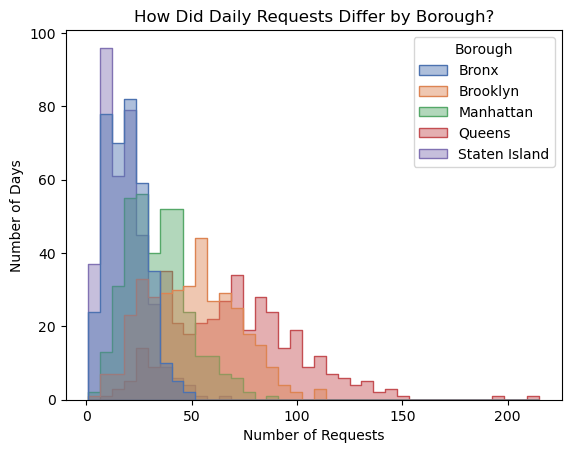

In [53]:
# Write your code here.
sns.histplot(data=daily_requests,
             x='request_count',
             hue='borough',
             hue_order=borough_order,
             element='step',
             alpha=0.45,
             palette='deep'
            )

plt.gca().get_legend().set_title('Borough')
plt.title('How Did Daily Requests Differ by Borough?')
plt.xlabel('Number of Requests')
plt.ylabel('Number of Days')
plt.show()
             

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: The histogram shows how many requests are made between the borough and how many days that number of requests are made throughout the year. The way the boroughs overlay each other makes it difficult to compare, especially in the 0-50 range on the x-axis. The colors representing each borough is changed when overlayed with another borough's color. 


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


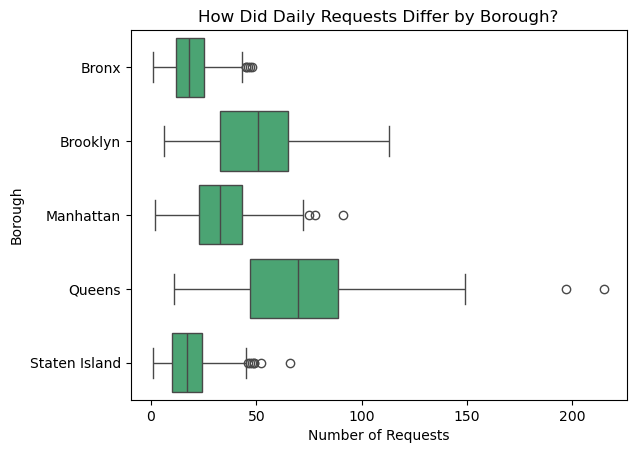

In [54]:
# Write your code here.
sns.boxplot(data=daily_requests,
            x='request_count',
            y='borough',
            order=borough_order,
            color='mediumseagreen')

plt.title('How Did Daily Requests Differ by Borough?')
plt.ylabel('Borough')
plt.xlabel('Number of Requests')
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer:The distribution is easier to see in the box plot. The box makes the median and the middle 50% of the data (25-75%) and the spread of the daily requests counts easier to identify and compare.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


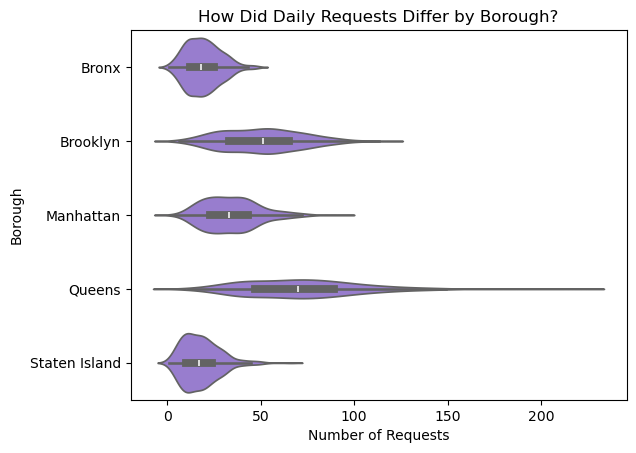

In [55]:
# Write your code here.
sns.violinplot(data=daily_requests,
            x='request_count',
            y='borough',
            order=borough_order,
            color='mediumpurple')

plt.title('How Did Daily Requests Differ by Borough?')
plt.ylabel('Borough')
plt.xlabel('Number of Requests')
plt.show()

**What does the violin plot add to the comparison?**

Your answer: The violin plot makes it easier to see where daily request counts are concentrated, showing the skewness of the distributions, and how consistent the number of requests are within each borough.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The violin plot, since, as I explained above, it shows how evenly the requests are concentrated amongst the days. A box plot fits everything inside a box, not showing if there is a more consistent number of requests received. The violin plot has the box plot info, but also combines the viewing of the histplot().


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Queens has more requests than the other boroughs. My prediction of Manhattan was not supported, as Manhattan comes third in the list


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: The request counts are solely based on the number of requests called in. Several people could have made a request pertaining to one singular street problem. This data could theoretically show that just more people are calling from Queens than the other boroughs, not necessarily that Queens has more issues than the others. 


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How did the average number of reported street-condition requests differ by month in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: The original feature will be the created_date feature. Each row will represent one day, with the month and number of requests reported on that day.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [56]:
# Write your code here.
requests['month'] = requests['date'].dt.month_name()

monthly_daily_requests = requests.groupby(['date', 'month']).size().reset_index(name='request_count')

monthly_daily_requests

,date,month,request_count
0,2025-01-01,January,189
1,2025-01-02,January,240
2,2025-01-03,January,136
3,2025-01-04,January,110
4,2025-01-05,January,155
...,...,...,...
360,2025-12-27,December,72
361,2025-12-28,December,118
362,2025-12-29,December,200
363,2025-12-30,December,196


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: The quantitative feature is the number of requests received on each day. I created a new column of months from the date (taken from created_date) so I can then group the daily request counts by month and compare the average daily number of daily requests across the months.


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [57]:
# Write your code here.
monthly_daily_requests[['date', 'month', 'request_count']].isnull().sum()

date             0
month            0
request_count    0
dtype: int64

In [58]:
monthly_daily_requests.groupby('month')['request_count'].describe()

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
April,30.0,221.666667,58.439083,114.0,171.25,245.0,272.75,289.0
August,31.0,180.161290,52.436690,72.0,136.50,201.0,213.50,294.0
December,31.0,155.419355,56.200103,40.0,105.50,162.0,198.00,254.0
February,28.0,200.535714,71.319044,95.0,149.00,189.0,258.00,362.0
January,31.0,176.322581,64.229478,57.0,126.00,187.0,229.00,289.0
July,31.0,197.290323,66.355203,63.0,136.00,213.0,244.50,301.0
June,30.0,241.066667,76.516815,109.0,161.25,266.5,303.25,348.0
March,31.0,226.258065,68.748318,118.0,151.00,239.0,279.00,328.0
May,31.0,239.903226,81.063907,124.0,164.50,257.0,301.00,426.0


In [59]:
month_order=['January', 'February', 'March', 'April', 'May', 'June', 
             'July', 'August', 'September', 'October', 'November',
             'December']

**What did your checks establish?**

Your answer: That there are no missing values in any of the columns of my new data frame and that there are no impossible or missing values.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


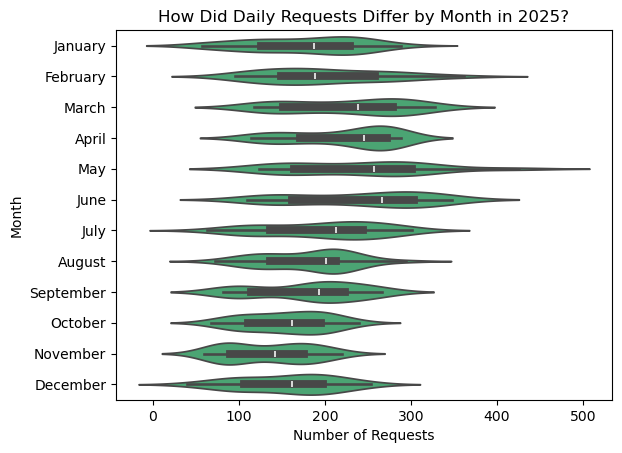

In [60]:
# Write your code here.
sns.violinplot(data=monthly_daily_requests,
               x='request_count',
               y='month',
               order=month_order,
               color='mediumseagreen'
              )

plt.title('How Did Daily Requests Differ by Month in 2025?')
plt.ylabel('Month')
plt.xlabel('Number of Requests')
plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The strongest evidence is that the median daily request count is slightly higher in June than in other months. The distributions are relatively similar across the months, suggesting there isn't that large of a difference in daily requests throughout the year, when calculated by month.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: The average number of reported street-condition requests was relatively similar across the months in 2025. June had the highest median daily request count, but the distributions were relatively similar. The evidence does not show a strong difference in daily request counts based on the month.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: The data represents reported street-condition requests rather than unique street-condition problems. The number of requests may depend on people's willingness to report an issue, so differences in the months may reflect reporting behavior as well as actual differences in street conditions.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I used Google's response when looking up how to create the borough_summary. I was having trouble with grouping by and selecting, so learning the differences between () and [] in terms of parameters and selection.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.


In [63]:
# Integrative Learning 1
# load data
starbucks = pd.DataFrame({
    'Time_of_Day': [
        'Morning', 'Morning', 'Morning', 'Morning', 'Morning',
        'Morning', 'Morning', 'Morning', 'Morning', 'Morning',
        'Afternoon', 'Afternoon', 'Afternoon', 'Afternoon', 'Afternoon',
        'Afternoon', 'Afternoon', 'Afternoon', 'Afternoon', 'Afternoon'
    ],
    'Wait_Time': [
        3.2, 4.5, 2.8, 5.1, 3.7, 8.6, 6.2, 7.5, 5.8, 4.1,
        3.6, 4.0, 2.9, 9.1, 3.5, 4.2, 6.6, 4.3, 5.9, 4.4
    ]
})

starbucks

,Time_of_Day,Wait_Time
0,Morning,3.2
1,Morning,4.5
2,Morning,2.8
3,Morning,5.1
4,Morning,3.7
5,Morning,8.6
6,Morning,6.2
7,Morning,7.5
8,Morning,5.8
9,Morning,4.1


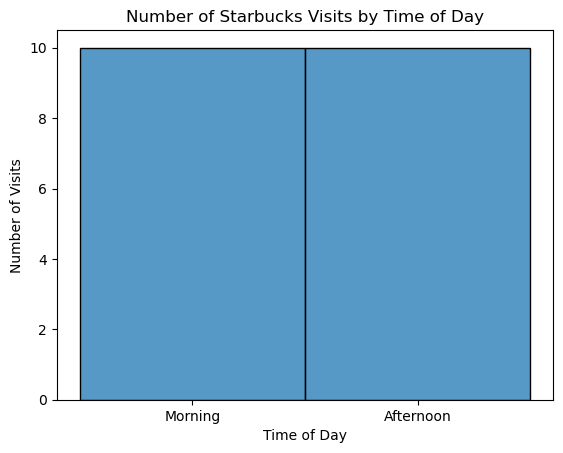

In [68]:
# Integrative Learning 1
# Categorical Chart
sns.histplot(data=starbucks, x='Time_of_Day')

plt.title('Number of Starbucks Visits by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Visits')
plt.show()

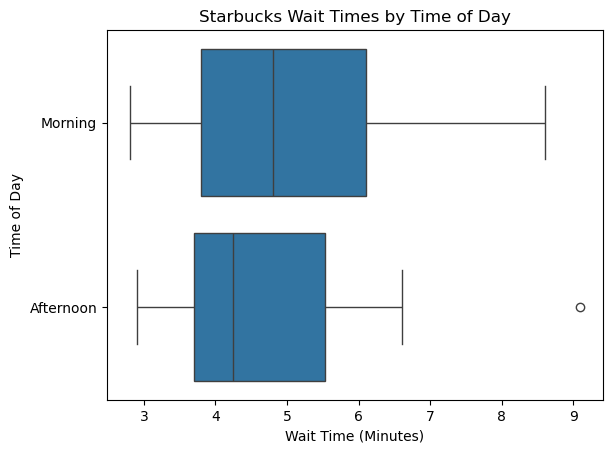

In [69]:
# Integrative Learning 1
# Quantitative Chart
sns.boxplot(
    data=starbucks,
    x="Wait_Time",
    y='Time_of_Day',
    order=['Morning', 'Afternoon']
)

plt.title('Starbucks Wait Times by Time of Day')
plt.xlabel('Wait Time (Minutes)')
plt.ylabel('Time of Day')
plt.show()

In [70]:
# Integrative Learning 1
# Mean
starbucks.groupby('Time_of_Day')['Wait_Time'].mean()

Time_of_Day
Afternoon    4.85
Morning      5.15
Name: Wait_Time, dtype: float64